In [ ]:
# import pandas as pd
# train_csv_path = '/content/gtsrb-german-traffic-sign/Train.csv'
# test_csv_path = '/content/gtsrb-german-traffic-sign/Test.csv'

# # Load the metadata into DataFrames
# train_df = pd.read_csv(train_csv_path)
# test_df = pd.read_csv(test_csv_path)

In [ ]:
# import cv2
# import numpy as np
# from tensorflow.keras.utils import to_categorical #canvair per la versió que toca
# # Define constants
# IMG_HEIGHT, IMG_WIDTH = 32, 32  # Standard size for CNNs
# NUM_CLASSES = 43  # Total number of traffic sign classes

# # Function to load and preprocess images
# def load_and_preprocess_image(path, img_size=(IMG_HEIGHT, IMG_WIDTH)):
#     img = cv2.imread(f'/content/gtsrb-german-traffic-sign/{path}')
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
#     img = cv2.resize(img, img_size)  # Resize to target size
#     img = img / 255.0  # Normalize pixel values to [0, 1]
#     return img

# # Load training images and labels
# X_train = np.array([load_and_preprocess_image(path) for path in train_df['Path']])
# y_train = train_df['ClassId'].values

# # One-hot encode labels
# y_train = to_categorical(y_train, NUM_CLASSES)


# X_test = np.array([load_and_preprocess_image(path) for path in test_df['Path']])
# y_test = test_df['ClassId'].values

# # One-hot encode labels
# y_test = to_categorical(y_test, NUM_CLASSES)

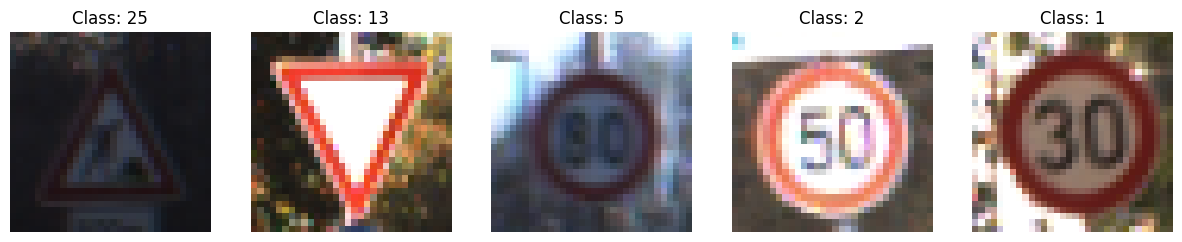

In [ ]:
# import matplotlib.pyplot as plt
# import random
# def plot_sample_images(data, labels, num_samples=5):
#     fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
#     for i in range(num_samples):
#         idx = random.randint(0, len(data) - 1)
#         axes[i].imshow(data[idx])
#         axes[i].set_title(f"Class: {np.argmax(labels[idx])}")
#         axes[i].axis('off')
#     plt.show()

# # Plot sample training images
# plot_sample_images(X_train, y_train)

In [1]:
!sudo apt-get update
!sudo apt-get install python2.7 python2.7-dev -y
!wget https://bootstrap.pypa.io/pip/2.7/get-pip.py
!python2.7 get-pip.py

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,788 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,240 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Package


Fitxers necessaris:
```
cudnn-8.0-linux-x64-v6.0.tgz
cuda-repo-ubuntu1604_8.0.61-1_amd64.deb
german_traffic_signs.zip
Model1.py
Model2.py
Model3.py
Model1.h5
Model2.h5
Model3.h5
gen_diff.py
utils.py
configs.py
```



In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [2]:
!sudo apt-get --purge remove cuda
!sudo apt-get --purge remove nvidia-*
!sudo apt-get autoremove

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package 'cuda' is not installed, so not removed
0 upgraded, 0 newly installed, 0 to remove and 32 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'nvidia-driver-550-server' for glob 'nvidia-*'
Note, selecting 'nvidia-firmware-550-server-550.144.03' for glob 'nvidia-*'
Note, selecting 'nvidia-firmware-535-535.154.05' for glob 'nvidia-*'
Note, selecting 'nvidia-docker2' for glob 'nvidia-*'
Note, selecting 'nvidia-firmware-560-server-560.28.03' for glob 'nvidia-*'
Note, selecting 'nvidia-driver-570-server' for glob 'nvidia-*'
Note, selecting 'nvidia-cuda-toolkit-doc' for glob 'nvidia-*'
Note, selecting 'nvidia-imex' for glob 'nvidia-*'
Note, selecting 'nvidia-dkms-450-server' for glob 'nvidia-*'
Note, selecting 'nvidia-firmware-535-server-535.154.05' for glob 'nvidia-*'
Note, selecting 'nvidia-headless-390' for glob

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!sudo dpkg -i /content/TFG/Entorn/cuda-repo-ubuntu1604_8.0.61-1_amd64.deb
!sudo apt-key adv --keyserver keyserver.ubuntu.com --recv-keys A4B469963BF863CC
!sudo apt-key adv --keyserver keyserver.ubuntu.com --recv-keys A4B469963BF863CC
!sudo apt-get update

Selecting previously unselected package cuda-repo-ubuntu1604.
(Reading database ... 127017 files and directories currently installed.)
Preparing to unpack .../cuda-repo-ubuntu1604_8.0.61-1_amd64.deb ...
Unpacking cuda-repo-ubuntu1604 (8.0.61-1) ...
Setting up cuda-repo-ubuntu1604 (8.0.61-1) ...
Note: Check first if apt-key functionality is needed at all - it probably isn't!
OK
Executing: /tmp/apt-key-gpghome.DYgEJFZ83v/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys A4B469963BF863CC
gpg: key A4B469963BF863CC: public key "cudatools <cudatools@nvidia.com>" imported
gpg: Total number processed: 1
gpg:               imported: 1
Executing: /tmp/apt-key-gpghome.HjOns7b7Zm/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys A4B469963BF863CC
gpg: key A4B469963BF863CC: "cudatools <cudatools@nvidia.com>" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvid

In [5]:
!sudo apt-get install cuda-8-0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cpp-12 cuda-command-line-tools-8-0 cuda-core-8-0 cuda-cublas-8-0
  cuda-cublas-dev-8-0 cuda-cudart-8-0 cuda-cudart-dev-8-0 cuda-cufft-8-0
  cuda-cufft-dev-8-0 cuda-curand-8-0 cuda-curand-dev-8-0 cuda-cusolver-8-0
  cuda-cusolver-dev-8-0 cuda-cusparse-8-0 cuda-cusparse-dev-8-0
  cuda-demo-suite-8-0 cuda-documentation-8-0 cuda-driver-dev-8-0 cuda-drivers
  cuda-drivers-570 cuda-license-8-0 cuda-misc-headers-8-0 cuda-npp-8-0
  cuda-npp-dev-8-0 cuda-nvgraph-8-0 cuda-nvgraph-dev-8-0 cuda-nvml-dev-8-0
  cuda-nvrtc-8-0 cuda-nvrtc-dev-8-0 cuda-runtime-8-0 cuda-samples-8-0
  cuda-toolkit-8-0 cuda-visual-tools-8-0 dctrl-tools default-jre
  default-jre-headless dkms fakeroot fonts-dejavu-core fonts-dejavu-extra
  freeglut3 freeglut3-dev gcc-12 keyboard-configuration libasan8
  libatk-wrapper-java libatk-wrapper-java-jni libegl-dev libfakeroot
  li

In [6]:
!apt-cache show cuda | grep Version

Version: 12.8.1-1
Version: 12.8.0-1
Version: 12.6.3-1
Version: 12.6.2-1
Version: 12.6.1-1
Version: 12.6.0-1
Version: 12.5.1-1
Version: 12.5.0-1
Version: 12.4.1-1
Version: 12.4.0-1
Version: 12.3.2-1
Version: 12.3.1-1
Version: 12.3.0-1
Version: 12.2.2-1
Version: 12.2.1-1
Version: 12.2.0-1
Version: 12.1.1-1
Version: 12.1.0-1
Version: 12.0.1-1
Version: 12.0.0-1
Version: 11.8.0-1
Version: 11.7.1-1
Version: 11.7.0-1
Version: 11.3.1-1
Version: 11.3.0-1
Version: 11.2.2-1
Version: 11.2.1-1
Version: 11.2.0-1
Version: 11.1.1-1
Version: 11.1.0-1
Version: 11.0.3-1
Version: 11.0.2-1
Version: 11.0.1-1
Version: 10.2.89-1
Version: 10.1.243-1
Version: 10.1.168-1
Version: 10.1.105-1
Version: 10.0.130-1
Version: 9.2.148-1
Version: 9.2.88-1
Version: 9.1.85-1
Version: 9.0.176-1
Version: 8.0.61-1
Version: 8.0.44-1


In [7]:
import os
os.environ['PATH'] = '/usr/local/cuda-8.0/bin:' + os.environ['PATH']
os.environ['CUDADIR'] = '/usr/local/cuda-8.0'
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-8.0/lib64:' + os.environ['LD_LIBRARY_PATH']


In [8]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2016 NVIDIA Corporation
Built on Tue_Jan_10_13:22:03_CST_2017
Cuda compilation tools, release 8.0, V8.0.61


In [ ]:
!tar -xzvf /content/TFG/Entorn/cudnn-8.0-linux-x64-v6.0.tgz -C /content/

cuda/include/cudnn.h
cuda/lib64/libcudnn.so
cuda/lib64/libcudnn.so.6
cuda/lib64/libcudnn.so.6.0.21
cuda/lib64/libcudnn_static.a


In [10]:
!sudo cp -P /content/cuda/include/cudnn.h /usr/local/cuda-8.0/include
!sudo cp -P /content/cuda/lib64/libcudnn* /usr/local/cuda-8.0/lib64/

In [11]:
!sudo chmod a+r /usr/local/cuda-8.0/lib64/libcudnn*

In [16]:
!python2.7 -m pip install tensorflow-gpu==1.3.0 keras==2.0.8 pillow h5py opencv-python==3.4.1.15 pandas==0.24.2 scikit-learn==0.18.2


     |████████████████████████████████| 158.8 MB 60 kB/s 
     |████████████████████████████████| 276 kB 66.3 MB/s 
     |████████████████████████████████| 2.1 MB 46.9 MB/s 
     |████████████████████████████████| 2.8 MB 85.7 MB/s 
     |████████████████████████████████| 24.9 MB 358 kB/s 
     |████████████████████████████████| 10.1 MB 62.3 MB/s 
     |████████████████████████████████| 11.6 MB 84 kB/s 
     |████████████████████████████████| 1.6 MB 64.9 MB/s 
     |████████████████████████████████| 1.0 MB 47.0 MB/s 
     |████████████████████████████████| 17.0 MB 68.5 MB/s 
     |████████████████████████████████| 24.8 MB 1.2 MB/s 
     |████████████████████████████████| 574 kB 68.4 MB/s 
     |████████████████████████████████| 509 kB 77.5 MB/s 
     |████████████████████████████████| 229 kB 79.7 MB/s 
     |████████████████████████████████| 298 kB 66.3 MB/s 
     |████████████████████████████████| 87 kB 7.6 MB/s 
     |████████████████████████████████| 889 kB 69.5 MB/s 
  Created wheel

In [17]:
!python2.7 -c "import keras; print(keras.__version__)"

Using TensorFlow backend.
2.0.8


In [ ]:
import zipfile
with zipfile.ZipFile("/content/TFG/german_traffic_signs.zip", "r") as zip_ref:
    zip_ref.extractall("/content/gtsrb-german-traffic-sign")

In [ ]:
!python2.7 /content/TFG/DeepXplore/GTSRB/Models_123/Model1.py

Using TensorFlow backend.
/content/drive/MyDrive/GIA/TFG/Senyals_deepXplore/Material/Bons_Models
(39209, 64, 64, 3)
Train on 39209 samples, validate on 12630 samples
Epoch 1/15
2025-03-18 19:56:58.851689: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.1 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-18 19:56:58.851722: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-18 19:56:58.851732: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX instructions, but these are available on your machine and could speed up CPU computations.
2025-03-18 19:56:58.851742: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX2 instructions, but these

In [ ]:
!python2.7 /content/TFG/DeepXplore/GTSRB/Models_123/Model2.py

Using TensorFlow backend.
(39209, 64, 64, 3)
Train on 39209 samples, validate on 12630 samples
Epoch 1/20
2025-03-19 12:15:29.739300: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.1 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 12:15:29.739334: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 12:15:29.739345: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 12:15:29.739353: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX2 instructions, but these are available on your machine and could speed up CPU computations.
202

In [ ]:
!python2.7 /content/TFG/DeepXplore/GTSRB/Models_123/Model3.py

Using TensorFlow backend.
(39209, 64, 64, 3)
Train on 39209 samples, validate on 12630 samples
Epoch 1/20
2025-03-18 19:42:11.047685: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.1 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-18 19:42:11.047730: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-18 19:42:11.047746: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX instructions, but these are available on your machine and could speed up CPU computations.
2025-03-18 19:42:11.047760: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX2 instructions, but these are available on your machine and could speed up CPU computations.
202

In [ ]:
!rm -rf /content/generated_inputs

In [ ]:
!mkdir /content/generated_inputs/

In [ ]:
import time
start_time = time.time()
!python2.7 /content/TFG/DeepXplore/GTSRB/Models_123/gen_diff.py occl 1 0.1 10 100 100 0 -t 0 -sp 10,10 > output_trafficsigns_occl0_ini.txt
end_time = time.time()

execution_time = end_time - start_time
execution_time_minutes = execution_time / 60

print(f"Execution Time: {execution_time_minutes:.2f} minutes")

Using TensorFlow backend.
2025-03-19 14:15:15.964940: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.1 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:15:15.964972: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:15:15.964982: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:15:15.964990: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:15:15.964998: W tensorflow/core/platform/cpu_feature_guard.cc:45] The

In [ ]:
import shutil
shutil.make_archive("/content/generated_inputs_trafficsigns_occl0_ini", 'zip', "/content/generated_inputs")

'/content/generated_inputs_trafficsigns_occl0_ini.zip'

In [ ]:
from google.colab import files
files.download("/content/generated_inputs_trafficsigns_occl0_ini.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/output_trafficsigns_occl0_ini.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!rm -rf /content/generated_inputs
!mkdir /content/generated_inputs

In [ ]:
import time
start_time = time.time()
!python2.7 /content/TFG/DeepXplore/GTSRB/Models_123/gen_diff.py blackout 1 0.1 10 100 100 0 -t 1 > output_trafficsigns_blackout1.txt
end_time = time.time()

execution_time = end_time - start_time
execution_time_minutes = execution_time / 60

print(f"Execution Time: {execution_time_minutes:.2f} minutes")

Using TensorFlow backend.
2025-03-19 14:03:27.247646: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.1 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:03:27.247691: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:03:27.247703: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:03:27.247711: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:03:27.247719: W tensorflow/core/platform/cpu_feature_guard.cc:45] The

In [ ]:
shutil.make_archive("/content/generated_inputs_trafficsigns_blackout1", 'zip', "/content/generated_inputs")
files.download("/content/generated_inputs_trafficsigns_blackout1.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/output_trafficsigns_blackout1.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!rm -rf /content/generated_inputs
!mkdir /content/generated_inputs

In [ ]:
import time
start_time = time.time()
!python2.7 /content/TFG/DeepXplore/GTSRB/Models_123/gen_diff.py blackout 1 0.1 10 100 100 0 -t 2 > output_trafficsigns_blackout2.txt
end_time = time.time()

execution_time = end_time - start_time
execution_time_minutes = execution_time / 60

print(f"Execution Time: {execution_time_minutes:.2f} minutes")

Using TensorFlow backend.
2025-03-19 14:07:17.562013: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.1 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:07:17.562099: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use SSE4.2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:07:17.562119: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:07:17.562131: W tensorflow/core/platform/cpu_feature_guard.cc:45] The TensorFlow library wasn't compiled to use AVX2 instructions, but these are available on your machine and could speed up CPU computations.
2025-03-19 14:07:17.562143: W tensorflow/core/platform/cpu_feature_guard.cc:45] The

In [ ]:
shutil.make_archive("/content/generated_inputs_trafficsigns_blackout2", 'zip', "/content/generated_inputs")
files.download("/content/generated_inputs_trafficsigns_blackout2.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/output_trafficsigns_blackout2.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>